**Plots & Maps:**
Produces all final figures: LST and NDVI time series charts per Quartier, a choropleth map of warming rates across Zürich West, and LST–NDVI scatter plots. All figures are exported to the figures/ folder.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import contextily as ctx        # for basemaps
import cmcrameri.cm as cmc      # perceptually uniform scientific colormaps
from scipy.stats import pearsonr

**1. Load all processed outputs**

In [10]:
PROCESSED = Path("../data/processed/")
FIGURES   = Path("../figures/")
FIGURES.mkdir(exist_ok=True)

zonal_df   = pd.read_csv(PROCESSED / "03_zonal_statistics.csv", parse_dates=["date"])
trends_df  = pd.read_csv(PROCESSED / "03_trends.csv")
corr_df    = pd.read_csv(PROCESSED / "03_correlations_over_time.csv", parse_dates=["date"])
gdf_trends = gpd.read_file(PROCESSED / "03_trends_per_quartier.gpkg")

print(f"Zonal stats rows: {len(zonal_df)}")
print(f"Quartiere in trends: {len(trends_df)}")

Zonal stats rows: 168
Quartiere in trends: 12


**2. Figure 1 — LST and NDVI Time Series per Kreis**

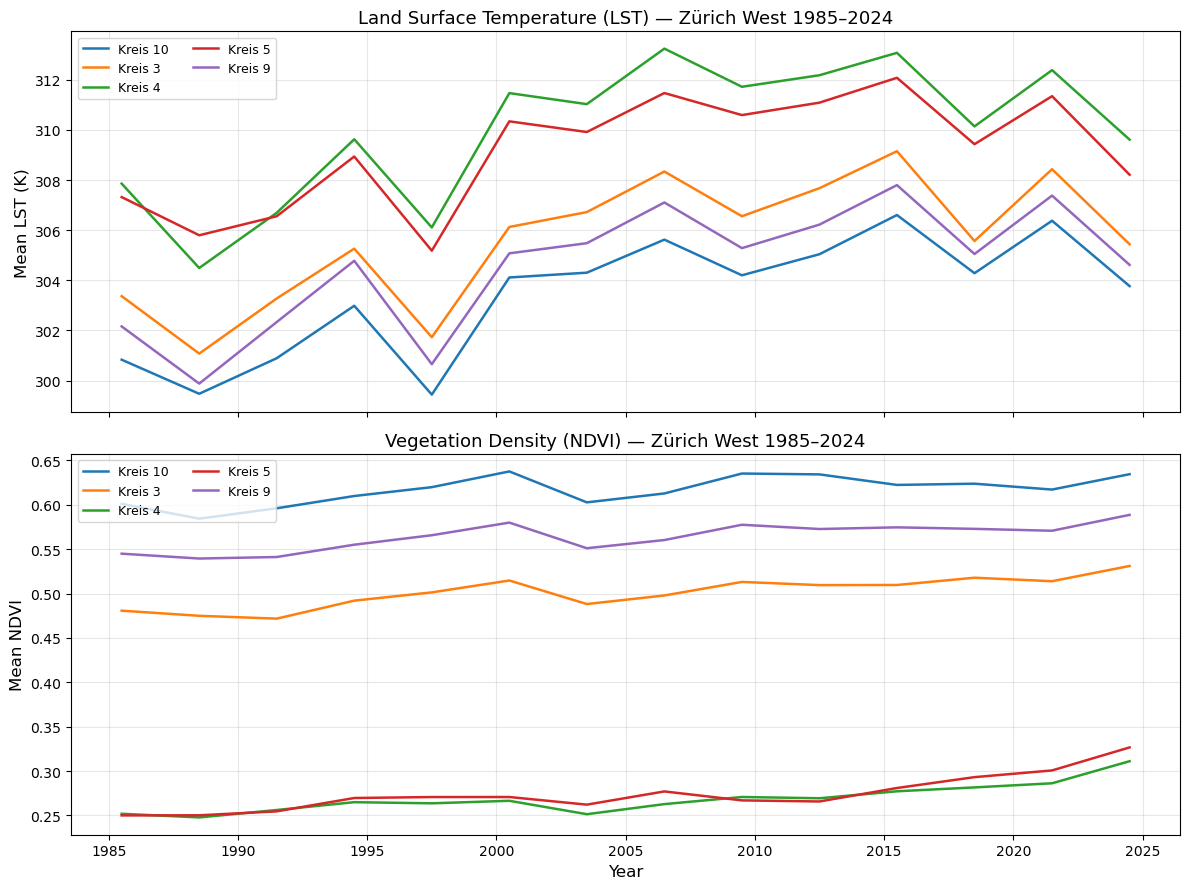

In [14]:
kreis_ts = zonal_df.groupby(["kreis", "date"])[["lst_mean", "ndvi_mean"]].mean().reset_index()

kreise = sorted(kreis_ts["kreis"].unique())
colors = plt.cm.tab10.colors  # one color per Kreis

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

for i, kreis in enumerate(kreise):
    subset = kreis_ts[kreis_ts["kreis"] == kreis].sort_values("date")
    ax1.plot(subset["date"], subset["lst_mean"],  color=colors[i], linewidth=1.8, label=f"{kreis}")
    ax2.plot(subset["date"], subset["ndvi_mean"], color=colors[i], linewidth=1.8, label=f"{kreis}")

ax1.set_ylabel("Mean LST (K)", fontsize=12)
ax1.set_title("Land Surface Temperature (LST) — Zürich West 1985–2024", fontsize=13)
ax1.legend(loc="upper left", fontsize=9, ncol=2)
ax1.grid(alpha=0.3)

ax2.set_ylabel("Mean NDVI", fontsize=12)
ax2.set_xlabel("Year", fontsize=12)
ax2.set_title("Vegetation Density (NDVI) — Zürich West 1985–2024", fontsize=13)
ax2.legend(loc="upper left", fontsize=9, ncol=2)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "04_timeseries_lst_ndvi_by_kreis.png", dpi=300, bbox_inches="tight")
plt.show()

**3.    Figure 2 — Choropleth Map: LST Warming Rate (°C or K per decade)**

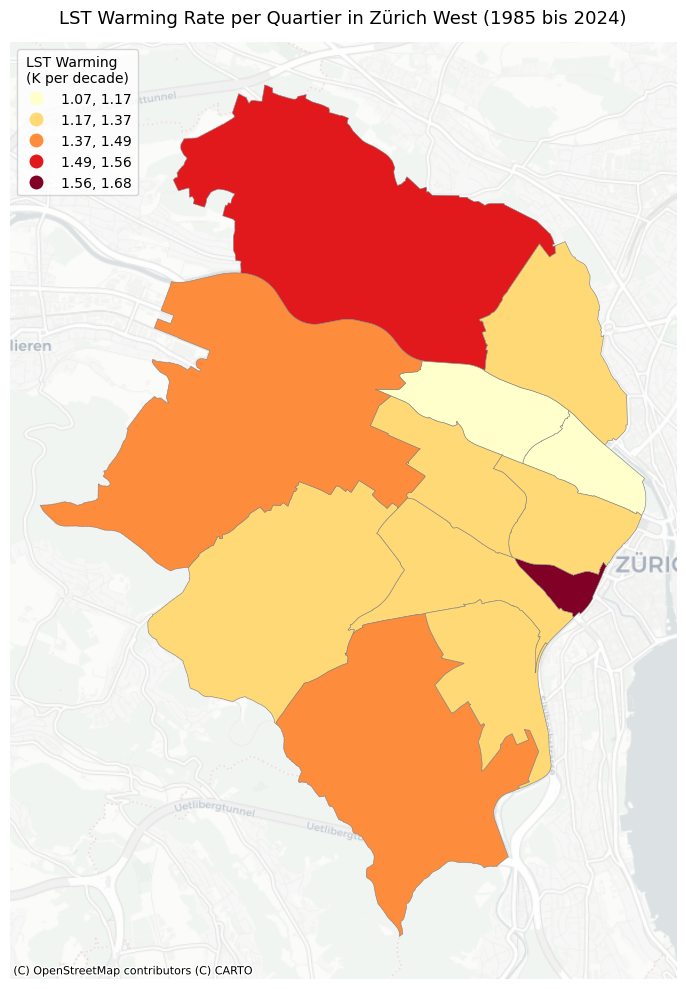

In [33]:
gdf_trends["lst_slope_per_decade"] = gdf_trends["lst_slope_per_yr"] * 10

# Reproject to Web Mercator for basemap tiles
gdf_web = gdf_trends.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_web.plot(
    ax=ax,
    column="lst_slope_per_decade",
    scheme="NaturalBreaks", # Automatische Klasseneinteilung nach Jenks
    k=5,                    # Definiert 5 dynamische Klassen
    cmap="YlOrRd",
    edgecolor="grey",
    linewidth=0.4,
    legend=True,
    legend_kwds={
        "title":    "LST Warming\n(K per decade)",
        "loc":      "upper left",
        "fontsize": 10,
    },
    missing_kwds={"color": "lightgrey", "label": "No data"},
)

# Add OpenStreetMap basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.8)

# Titel angepasst
ax.set_title("LST Warming Rate per Quartier in Zürich West (1985 bis 2024)", fontsize=13, pad=14)
ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES / "04_choropleth_lst_warming.png", dpi=300, bbox_inches="tight")
plt.show()

**4. Figure 3 — Choropleth Map: NDVI Change**

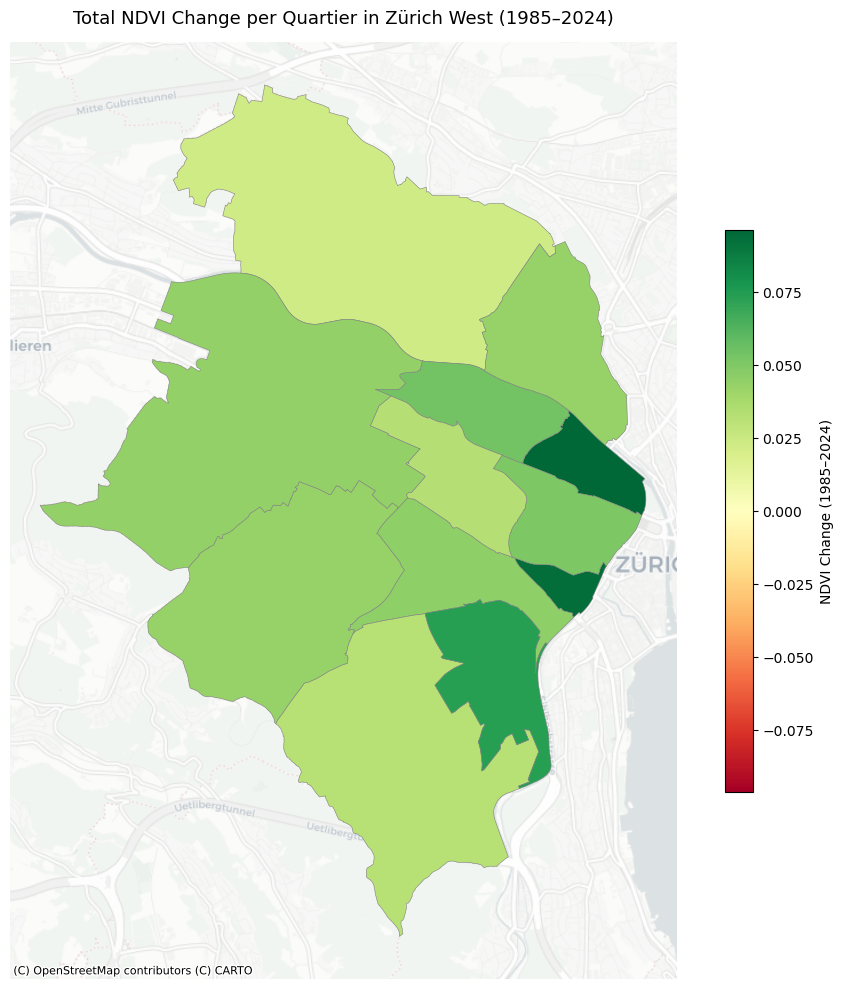

In [36]:
gdf_web_ndvi = gdf_trends.to_crs(epsg=3857)

# NDVI change: negative = vegetation loss (browning), positive = gain (greening)
ndvi_max = gdf_web_ndvi["ndvi_total_change"].abs().quantile(0.95)  # symmetric vmin/vmax

fig, ax = plt.subplots(figsize=(10, 10))

gdf_web_ndvi.plot(
    ax=ax,
    column="ndvi_total_change",
    cmap="RdYlGn",      # diverging: red=vegetation loss, green=gain
    vmin=-ndvi_max,
    vmax=ndvi_max,
    edgecolor="grey",
    linewidth=0.4,
    legend=True,
    legend_kwds={
        "label":    "NDVI Change (1985–2024)",
        "shrink":   0.6,
    },
    missing_kwds={"color": "lightgrey"},
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.8)

ax.set_title("Total NDVI Change per Quartier in Zürich West (1985–2024)", fontsize=13, pad=14)
ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES / "04_choropleth_ndvi_change.png", dpi=300, bbox_inches="tight")
plt.show()

**5. Figure 4 — LST–NDVI Scatter Plot with Regression Line**

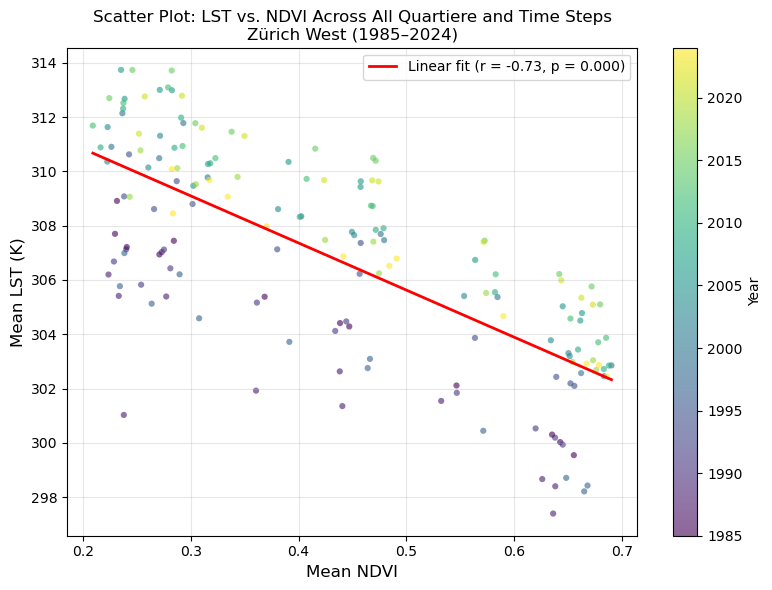

In [41]:
scatter_data = zonal_df.dropna(subset=["lst_mean", "ndvi_mean"])

# Compute Pearson r for annotation
r_val, p_val = pearsonr(scatter_data["lst_mean"], scatter_data["ndvi_mean"])

# Fit regression line
slope, intercept, *_ = np.polyfit(scatter_data["ndvi_mean"], scatter_data["lst_mean"], 1), None
m, b = np.polyfit(scatter_data["ndvi_mean"].values, scatter_data["lst_mean"].values, 1)

x_line = np.linspace(scatter_data["ndvi_mean"].min(), scatter_data["ndvi_mean"].max(), 200)
y_line = m * x_line + b

fig, ax = plt.subplots(figsize=(8, 6))

# Scatter coloured by year
sc = ax.scatter(
    scatter_data["ndvi_mean"],
    scatter_data["lst_mean"],
    c=scatter_data["date"].dt.year,
    cmap="viridis",
    alpha=0.6,
    s=20,
    edgecolors="none",
)
ax.plot(x_line, y_line, color="red", linewidth=2, label=f"Linear fit (r = {r_val:.2f}, p = {p_val:.3f})")

fig.colorbar(sc, ax=ax, label="Year")
ax.set_xlabel("Mean NDVI", fontsize=12)
ax.set_ylabel("Mean LST (K)", fontsize=12)
ax.set_title("Scatter Plot: LST vs. NDVI Across All Quartiere and Time Steps\nZürich West (1985–2024)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "04_scatter_lst_vs_ndvi.png", dpi=150, bbox_inches="tight")
plt.show()

**Test on Pearson Correlation**

**H0**: rho = 0             There is no significant linear correlation between LST and NDVI.


**H1**: rho is not 0        There is a significant linear correlation between LST and NDVI.


alpha = 0.05


In [44]:
test_data = zonal_df.dropna(subset=["lst_mean", "ndvi_mean"])

# Führe die Berechnung aus
r_val, p_val = pearsonr(test_data["lst_mean"], test_data["ndvi_mean"])
alpha = 0.05

print("Hyposis Testing: LST vs. NDVI")
print(f"Pearson r: {r_val:.4f}")
print(f"p-value:    {p_val:.4e}")
print(f"Alpha:     {alpha}\n")

# Werte das Resultat anhand des p-Wertes aus
if p_val < alpha:
    print("Decision: Reject the null hypothesis (H0).")
    print("Meaning: There is a statistically significant linear relationship between LST and NDVI.")
else:
    print("Decision: Fail to reject the null hypothesis (H0).")
    print("Meaning: There is no statistically significant linear relationship between LST and NDVI.")

Hyposis Testing: LST vs. NDVI
Pearson r: -0.7285
p-value:    4.5524e-29
Alpha:     0.05

Decision: Reject the null hypothesis (H0).
Meaning: There is a statistically significant linear relationship between LST and NDVI.


**6. Figure 5 — Small Multiples: Faceted Time Series per Quartier**

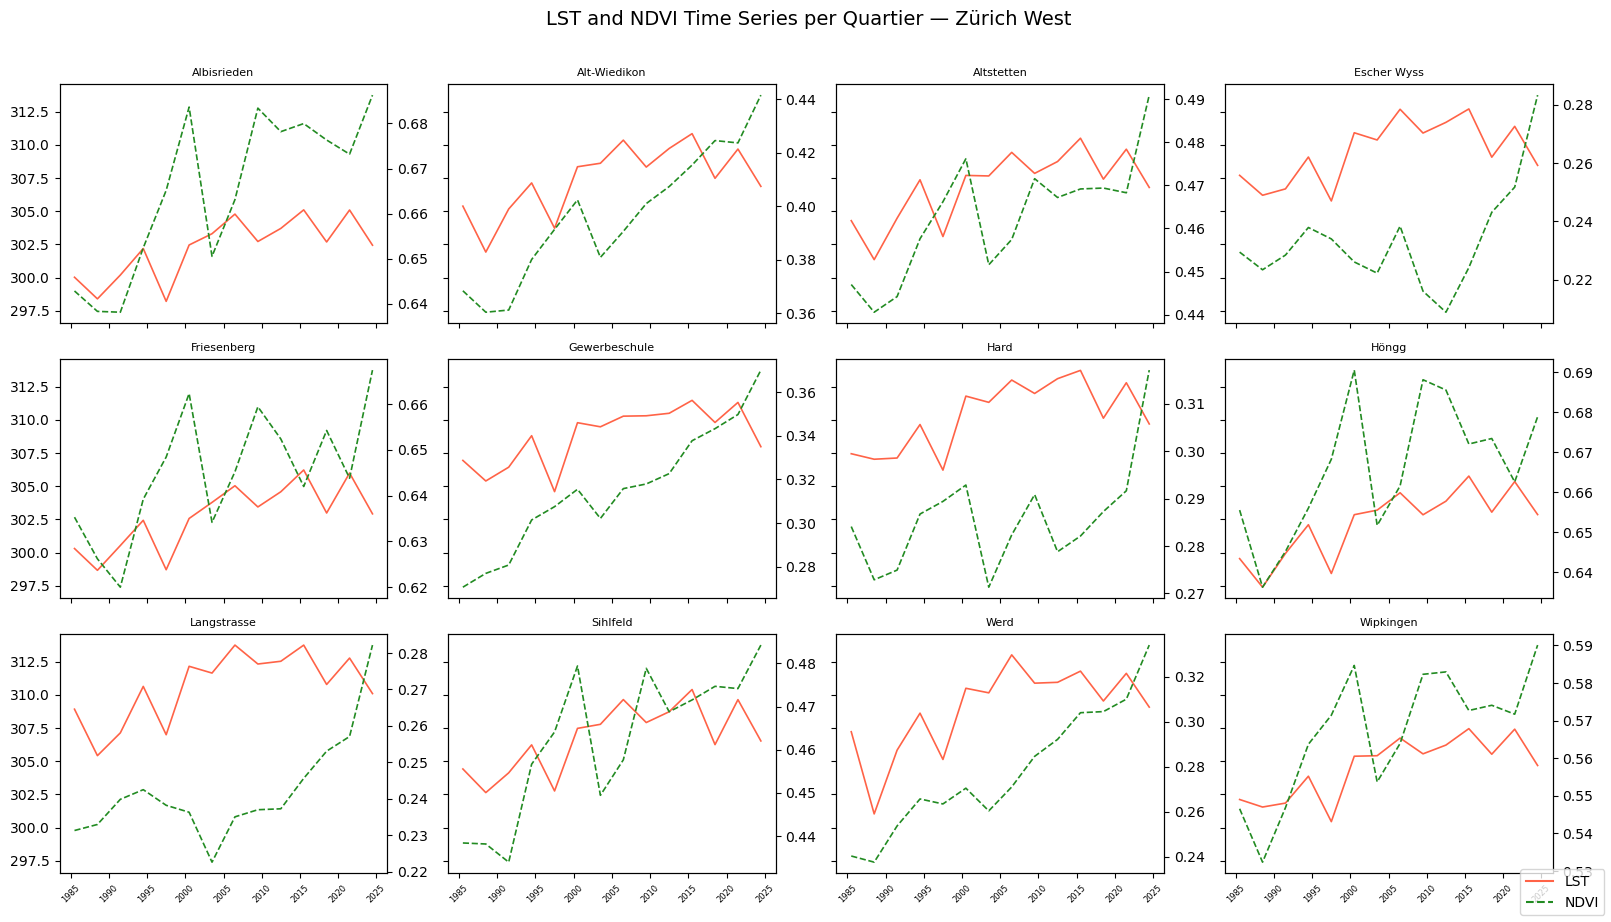

In [42]:
quartiere = sorted(zonal_df["quartier"].unique())
n_cols = 4
n_rows = (len(quartiere) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, q_name in enumerate(quartiere):
    ax = axes_flat[i]
    subset = zonal_df[zonal_df["quartier"] == q_name].sort_values("date")
    ax.plot(subset["date"], subset["lst_mean"],  color="tomato", linewidth=1.2, label="LST")
    ax_r = ax.twinx()
    ax_r.plot(subset["date"], subset["ndvi_mean"], color="forestgreen", linewidth=1.2, linestyle="--", label="NDVI")
    ax.set_title(q_name, fontsize=8)
    ax.tick_params(axis="x", labelrotation=45, labelsize=6)

# Hide unused axes
for j in range(len(quartiere), len(axes_flat)):
    axes_flat[j].set_visible(False)

legend_elements = [Line2D([0], [0], color="tomato", lw=1.5, label="LST"),
                   Line2D([0], [0], color="forestgreen", lw=1.5, linestyle="--", label="NDVI")]
fig.legend(handles=legend_elements, loc="lower right", fontsize=10)
fig.suptitle("LST and NDVI Time Series per Quartier — Zürich West", fontsize=14, y=1.01)

plt.tight_layout()
plt.savefig(FIGURES / "04_faceted_timeseries_per_quartier.png", dpi=150, bbox_inches="tight")
plt.show()